# 05 - Evaluation, Visualization, and Error Analysis

In [1]:
from pathlib import Path
import sys,warnings
warnings.filterwarnings("ignore")
ROOT=Path.cwd(); ROOT=ROOT.parent if ROOT.name=="notebooks" else ROOT
sys.path.insert(0,str(ROOT)) if str(ROOT) not in sys.path else None
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils import *
ensure_dirs(); pd.set_option("display.max_columns",100)
print("Project root:",ROOT)
import joblib
from sklearn.inspection import permutation_importance

Project root: /Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER


In [2]:
pred=pd.read_csv(RESULTS_DIR/"test_predictions.csv",low_memory=False); metrics=pd.read_csv(RESULTS_DIR/"test_metrics.csv",index_col=0); display(metrics); best=metrics.MAE.idxmin(); col=f"pred_{best}"; print("Best:",best)

,MAE,RMSE,R2,MAPE_percent
BaselineMedian,11272.798250,15211.789275,-0.052855,133.468313
Ridge,6213.528505,9609.489446,0.579846,97.248188
RandomForest,3247.738759,6137.037022,0.828634,50.388304


Best: RandomForest


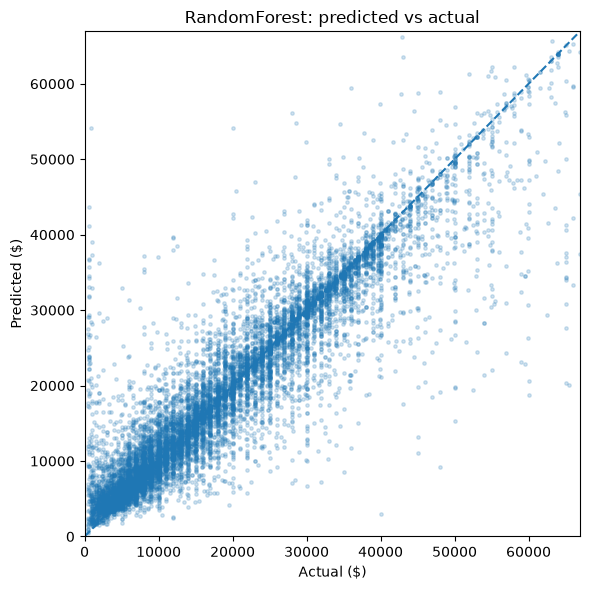

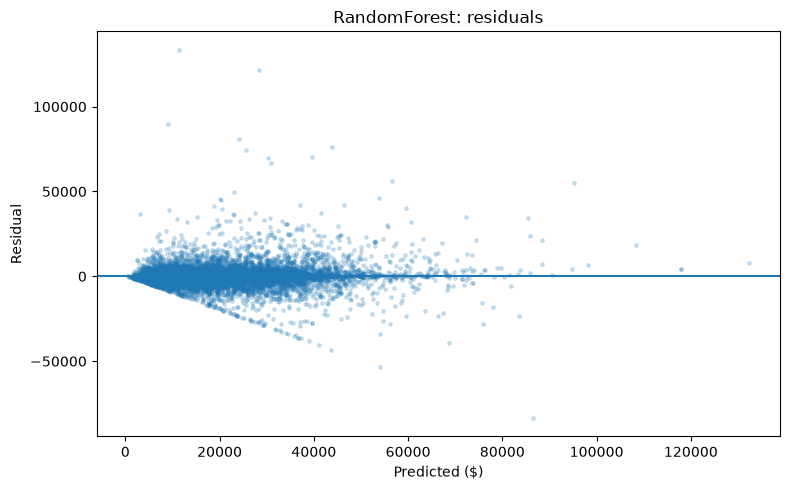

In [3]:
fig,ax=plt.subplots(figsize=(6,6)); lim=max(pred.actual_price.quantile(.99),pred[col].quantile(.99)); ax.scatter(pred.actual_price,pred[col],s=6,alpha=.2); ax.plot([0,lim],[0,lim],"--"); ax.set(xlim=(0,lim),ylim=(0,lim),xlabel="Actual ($)",ylabel="Predicted ($)",title=f"{best}: predicted vs actual"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"06_predicted_vs_actual.png",dpi=160); plt.show(); res=pred.actual_price-pred[col]; fig,ax=plt.subplots(figsize=(8,5)); ax.scatter(pred[col],res,s=6,alpha=.2); ax.axhline(0); ax.set(xlabel="Predicted ($)",ylabel="Residual",title=f"{best}: residuals"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"07_residuals.png",dpi=160); plt.show()

In [4]:
pred["absolute_error"]=(pred.actual_price-pred[col]).abs(); worst=pred.nlargest(20,"absolute_error"); display(worst[["actual_price",col,"absolute_error","manufacturer","car_age","odometer","type","state"]].head(10)); worst.to_csv(RESULTS_DIR/"worst_predictions.csv",index=False)

,actual_price,pred_RandomForest,absolute_error,manufacturer,car_age,odometer,type,state
4166,144832,11326.221634,133505.778366,volvo,8.0,144832.0,sedan,tx
9076,150000,28440.425495,121559.574505,porsche,52.0,60000.0,coupe,ny
8345,98772,9156.350246,89615.649754,toyota,8.0,89000.0,NaN,pa
6575,2986,86483.070380,83497.070380,ferrari,8.0,23158.0,convertible,wa
2556,105000,24118.856135,80881.143865,NaN,14.0,128000.0,truck,ok
4089,119900,43859.622795,76040.377205,NaN,6.0,202261.0,NaN,nc
1728,100000,25551.342360,74448.657640,dodge,49.0,2568.0,NaN,ca
5558,109999,39509.311554,70489.688446,mercedes-benz,3.0,31516.0,sedan,ny
10736,99995,30280.651812,69714.348188,NaN,51.0,999.0,convertible,wi
5177,98000,30956.329476,67043.670524,NaN,8.0,NaN,NaN,wi


In [5]:
segments={"luxury_actual_ge_50000":pred.actual_price>=50000,"very_old_age_ge_25":pred.car_age>=25,"high_mileage_ge_150k":pred.odometer>=150000,"other":(pred.actual_price<50000)&(pred.car_age<25)&(pred.odometer<150000)}; seg={};
for name,mask in segments.items():
 s=pred.loc[mask]; seg[name]={"n":int(len(s)),"MAE":float((s.actual_price-s[col]).abs().mean()) if len(s) else None}
display(pd.DataFrame(seg).T)

,n,MAE
luxury_actual_ge_50000,408.0,12764.413349
very_old_age_ge_25,549.0,6740.800793
high_mileage_ge_150k,2263.0,2280.828712
other,8823.0,2942.279016


/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possi

/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possi

/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possi

/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possi

,feature,importance
0,car_age,5122.595283
1,odometer,3744.177988
5,cylinders,2036.187781
9,drive,1831.368096
6,fuel,1437.385915
3,manufacturer,995.239156
10,type,936.056696
2,mileage_per_year,671.549189
4,condition,473.525809
8,transmission,288.743473


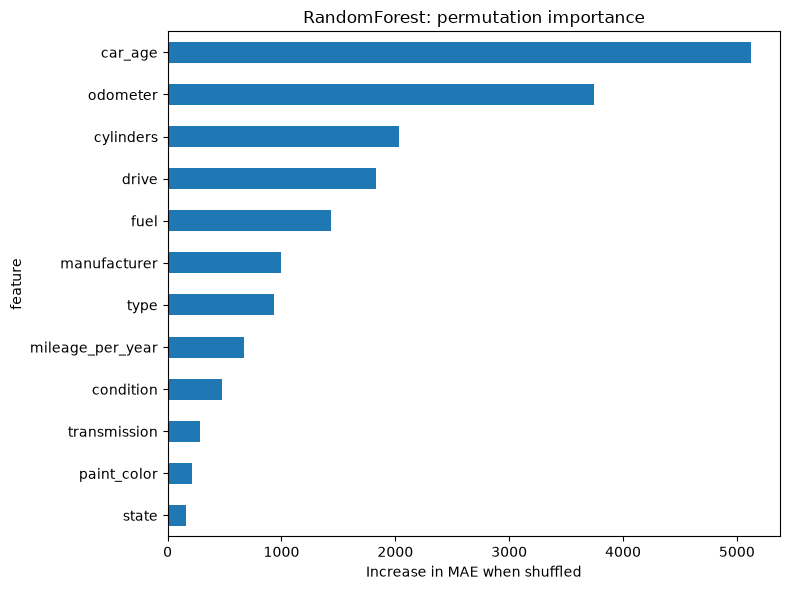

In [6]:
model=joblib.load(MODELS_DIR/("random_forest.joblib" if best=="RandomForest" else "ridge.joblib")); Xs=pred[FINAL_FEATURES].sample(min(len(pred),5000),random_state=RANDOM_STATE); ys=pred.loc[Xs.index,"actual_price"]; pi=permutation_importance(model,Xs,ys,n_repeats=3,random_state=RANDOM_STATE,scoring="neg_mean_absolute_error",n_jobs=-1); imp=pd.DataFrame({"feature":FINAL_FEATURES,"importance":pi.importances_mean}).sort_values("importance",ascending=False); display(imp.head(12)); imp.to_csv(RESULTS_DIR/"final_permutation_importance.csv",index=False); fig,ax=plt.subplots(figsize=(8,6)); imp.head(12).sort_values("importance").plot.barh(x="feature",y="importance",legend=False,ax=ax); ax.set(xlabel="Increase in MAE when shuffled",title=f"{best}: permutation importance"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"08_feature_importance.png",dpi=160); plt.show()

,median,count
state,,
ak,24999.0,115
la,24245.0,84
hi,23415.5,78
mt,22998.0,183
mo,21835.0,130
ar,21438.0,99
al,20917.0,151
wa,19999.0,397
tx,19950.0,685


,median,count
state,,
ma,12997.5,234
ia,12991.5,262
pa,12889.0,432
mi,12000.0,533
me,11977.0,75
va,11747.5,256
oh,11300.0,533
nh,11247.5,98
ct,10997.0,182


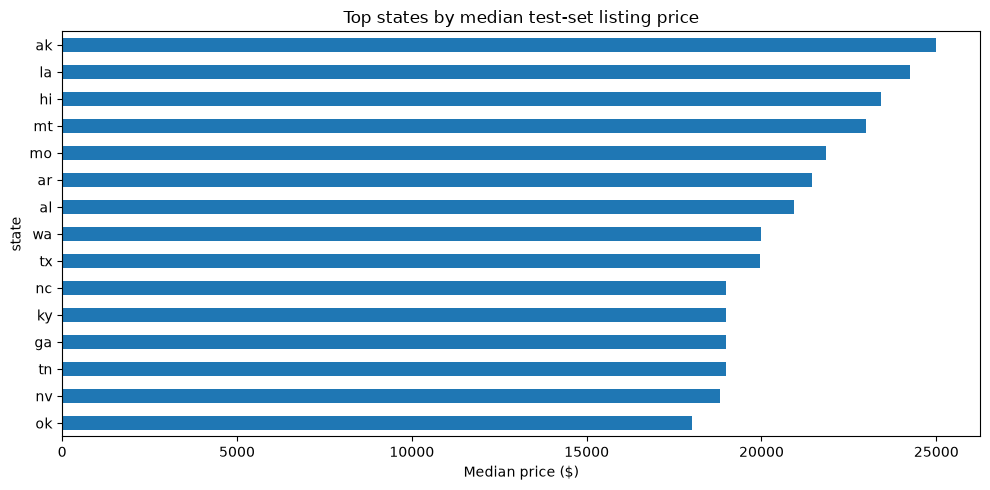

In [7]:
state=pred.groupby("state").actual_price.agg(["median","count"]).query("count>=50").sort_values("median",ascending=False); display(state.head(10)); display(state.tail(10)); state.to_csv(RESULTS_DIR/"test_state_price_stats.csv"); fig,ax=plt.subplots(figsize=(10,5)); state.head(15).sort_values("median")["median"].plot.barh(ax=ax); ax.set(xlabel="Median price ($)",title="Top states by median test-set listing price"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"09_state_median_price.png",dpi=160); plt.show()

In [8]:
top3=imp.head(3).feature.tolist(); sdf=pd.DataFrame(seg).T; worstseg=sdf.MAE.idxmax(); spread=float(state["median"].max()-state["median"].min()) if len(state) else float("nan"); qs={"q1":f"Top three features by permutation importance: {', '.join(top3)}.","q2":f"Among states with >=50 test listings, median-price spread was about ${spread:,.0f}; this is descriptive, not causal.","q3":f"Highest MAE among prespecified segments: {worstseg}."}; save_json({"best_model":best,"segment_mae":seg,"questions":qs},RESULTS_DIR/"error_analysis.json"); [print(k,v) for k,v in qs.items()]

q1 Top three features by permutation importance: car_age, odometer, cylinders.
q2 Among states with >=50 test listings, median-price spread was about $14,449; this is descriptive, not causal.
q3 Highest MAE among prespecified segments: luxury_actual_ge_50000.


[None, None, None]